In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import json
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import nomad.io.base as loader
import nomad.stop_detection.dbscan as TADBSCAN
from nomad.stop_detection.density_based import seqscan

import nomad.visit_attribution.visit_attribution as visits

from nomad.contact_estimation import compute_stop_detection_metrics
import warnings

from sklearn.cluster import DBSCAN

In [2]:
!pip install seaborn
!pip install -e /Users/caroltu/nomad

Obtaining file:///Users/caroltu/nomad
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for nomad (pyproject.toml) ... done
  Created wheel for nomad: filename=nomad-0.2.0-0.editable-py3-none-any.whl size=4768 sha256=cc07c7a740d3161ee285710815187683eae5111a4246aaa62aa8b2d01baaab21
  Stored in directory: /private/var/folders/f_/ltygyh2d33x4m6tkm0zzxw4h0000gn/T/pip-ephem-wheel-cache-moaldbr7/wheels/4c/0f/0e/23072ea399acebe804aa6bc4374af41a60c00844ba87f37248
Successfully built nomad
  Attempting uninstall: nomad
    Found existing installation: nomad 0.2.0
    Uninstalling nomad-0.2.0:
      Successfully uninstalled nomad-0.2.0


In [3]:
with open('config_2_stops.json', 'r', encoding='utf-8') as f:
    config = json.load(f)

In [4]:
poi_table = gpd.read_parquet(config["buildings_file"]).rename(columns={"id":"location"})
sparse_df = loader.from_file(config["output_files"]["sparse_path"], format="parquet")
diaries_df = loader.from_file(config["output_files"]["diaries_path"], format="parquet").rename(
    columns={"identifier":"user_id"})

In [5]:
# print(sparse_df)
sparse = sparse_df.loc[sparse_df.user_id == "admiring_mestorf"]
print(sparse)

               x             y            datetime   timestamp  \
0  -4.265454e+06  4.393131e+06 2024-06-01 00:07:18  1717214838   
1  -4.265448e+06  4.393141e+06 2024-06-01 00:14:53  1717215293   
2  -4.265441e+06  4.393122e+06 2024-06-01 00:24:23  1717215863   
3  -4.265434e+06  4.393146e+06 2024-06-01 00:25:11  1717215911   
4  -4.265449e+06  4.393124e+06 2024-06-01 00:50:13  1717217413   
5  -4.265391e+06  4.393143e+06 2024-06-01 01:35:02  1717220102   
6  -4.265398e+06  4.393154e+06 2024-06-01 01:47:11  1717220831   
7  -4.265405e+06  4.393139e+06 2024-06-01 01:50:01  1717221001   
8  -4.265405e+06  4.393157e+06 2024-06-01 01:52:55  1717221175   
9  -4.265405e+06  4.393158e+06 2024-06-01 02:04:03  1717221843   
10 -4.265396e+06  4.393163e+06 2024-06-01 02:04:47  1717221887   
11 -4.265402e+06  4.393162e+06 2024-06-01 02:05:21  1717221921   
12 -4.265416e+06  4.393140e+06 2024-06-01 02:13:37  1717222417   
13 -4.265403e+06  4.393170e+06 2024-06-01 02:14:28  1717222468   
14 -4.2654

In [6]:
db = DBSCAN(eps=12, min_samples=3).fit(sparse[["x","y"]])
db.labels_

array([ 0,  0,  0, -1,  0,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1])

In [7]:
warnings.filterwarnings('ignore', message='Input is timezone-naive; assuming UTC')

dist_thresh_values = np.linspace(1, 50, 100)

config["algos"] = {
    **{f"seqscan_dist_thresh_{int(dr)}": {
        "func": TADBSCAN.ta_dbscan,
        "params": {
            "time_thresh":60,
            "dist_thresh":dr,
            "min_pts":3
        }
    } for dr in dist_thresh_values}
}

results_list = []
for user in tqdm(diaries_df.user_id.unique(), desc='Processing users'):
    sparse = sparse_df.query("user_id==@user").copy()
    truth = diaries_df.query("user_id==@user").copy()
    
    # Run all st-dbscan parameterizations
    for algo_name, algo_config in config["algos"].items():
        # Run stop detection
        stops = algo_config["func"](sparse, **algo_config["params"], x="x", y="y", timestamp='timestamp')
        
        # Map stops to buildings
        stops["location"] = visits.point_in_polygon(
            stops, 
            poi_table=poi_table, 
            data_crs='EPSG:3857',
            max_distance=12, 
            location_id='location', 
            x='x', 
            y='y'
        )
        
        # Compute metrics
        metrics = compute_stop_detection_metrics(
            stops=stops,
            truth=truth,
            user_id=user,
            algorithm=algo_name,
            traj_cols={'location_id': 'location'},
            timestamp='timestamp'
        )
        
        # Add dist_thresh value to metrics
        metrics['dist_thresh'] = algo_config['params']['dist_thresh']
        
        results_list.append(metrics)

# Convert to DataFrame
results_df = pd.DataFrame(results_list)

print(f"Computed metrics for {len(results_df)} user-algorithm combinations")

Processing users: 100%|██████████| 100/100 [03:54<00:00,  2.34s/it]

Computed metrics for 5000 user-algorithm combinations


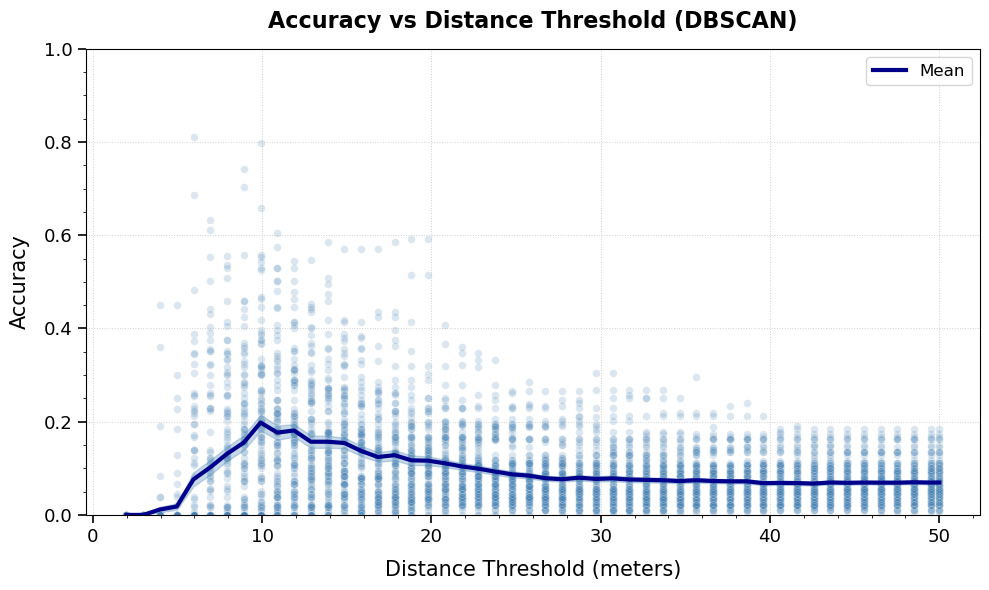

Number of unique dist_thresh values: 50


In [8]:
# Plotting function adapted for dist_thresh
def plot_metric_dist_thresh(metric, title, save_path='figures'):
    """Plot a metric vs dist_thresh for Lachesis."""
    chart_df = results_df.groupby(['dist_thresh'])[metric].agg(['mean', 'sem']).reset_index()

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Add scatter plot background (individual data points)
    sns.scatterplot(data=results_df, x='dist_thresh', y=metric,
                   alpha=0.2, s=30, ax=ax, color='steelblue')
    
    # Add line plot (mean values)
    ax.plot(chart_df['dist_thresh'], chart_df['mean'],
            color='darkblue', linewidth=3, label='Mean')
    
    # Add confidence band (mean ± SEM)
    ax.fill_between(chart_df['dist_thresh'],
                    chart_df['mean'] - chart_df['sem'],
                    chart_df['mean'] + chart_df['sem'],
                    alpha=0.3, color='steelblue')
    
    # Styling
    ax.set_xlabel('Distance Threshold (meters)', fontsize=15, labelpad=10)
    ax.set_ylabel(title, fontsize=15, labelpad=10)
    ax.set_ylim(0, 1)
    ax.set_title(f'{title} vs Distance Threshold (DBSCAN)', fontsize=16, pad=15, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=0.6, linewidth=0.7)
    ax.tick_params(axis='both', which='major', labelsize=13, length=6, width=1.2)
    ax.minorticks_on()
    ax.legend(fontsize=12, frameon=True, loc='best')
    
    plt.tight_layout()
    plt.savefig(f"{save_path}/dbscan_dist_thresh_{metric}.svg", bbox_inches='tight')
    plt.savefig(f"{save_path}/dbscan_dist_thresh_{metric}.png", dpi=600, bbox_inches='tight')
    plt.show(block=False)
    plt.close()

plot_metric_dist_thresh("recall", "Accuracy")
print(f"Number of unique dist_thresh values: {results_df['dist_thresh'].nunique()}")

In [ ]:
#gps like pings
print(sparse_df.head(5))

              x             y            datetime   timestamp  \
0 -4.265454e+06  4.393131e+06 2024-06-01 00:07:18  1717214838   
1 -4.265448e+06  4.393141e+06 2024-06-01 00:14:53  1717215293   
2 -4.265441e+06  4.393122e+06 2024-06-01 00:24:23  1717215863   
3 -4.265434e+06  4.393146e+06 2024-06-01 00:25:11  1717215911   
4 -4.265449e+06  4.393124e+06 2024-06-01 00:50:13  1717217413   

            user_id    ha  tz_offset  
0  admiring_mestorf  15.0     -14400  
1  admiring_mestorf  15.0     -14400  
2  admiring_mestorf  15.0     -14400  
3  admiring_mestorf  15.0     -14400  
4  admiring_mestorf  15.0     -14400  


In [ ]:
#ground truth locations
print(poi_table.head(5))

       index   location building_type  door_cell_x  door_cell_y  size  \
0  p-x12-y11  p-x12-y11          park           13           11    16   
1    h-x7-y8    h-x7-y8          home            8            8     2   
2    h-x9-y7    h-x9-y7          home            9            8     2   
3   h-x10-y7   h-x10-y7          home           10            8     1   
4   h-x11-y7   h-x11-y7          home           11            8     1   

   door_point_x  door_point_y  \
0          13.0          11.5   
1           8.0           8.5   
2           9.5           8.0   
3          10.5           8.0   
4          11.5           8.0   

                                            geometry  
0  POLYGON ((-4265504 4393111, -4265504 4393171, ...  
1  POLYGON ((-4265594 4393081, -4265579 4393081, ...  
2  POLYGON ((-4265579 4393081, -4265549 4393081, ...  
3  POLYGON ((-4265534 4393081, -4265534 4393096, ...  
4  POLYGON ((-4265519 4393081, -4265519 4393096, ...  


In [ ]:
# ground truth visits
print(diaries_df.head(5))

             datetime   timestamp  duration   location              user_id  \
0 2024-06-01 00:00:12  1717214412        90  w-x17-y10     admiring_mestorf   
1 2024-06-01 01:30:12  1717219812         0       None     admiring_mestorf   
2 2024-06-01 01:31:00  1717219860        89  r-x19-y11     admiring_mestorf   
3 2024-06-01 00:00:12  1717214412        90  w-x17-y10  affectionate_carson   
4 2024-06-01 01:30:12  1717219812         1       None  affectionate_carson   

           x          y  tz_offset  
0 -4265429.0  4393133.5     -14400  
1        NaN        NaN     -14400  
2 -4265414.0  4393148.5     -14400  
3 -4265429.0  4393133.5     -14400  
4        NaN        NaN     -14400  


In [ ]:


# def seqscan(
#     df: pd.DataFrame,
#     eps: float,
#     min_samples: int = 3,
#     user_id: str | None = None,
#     x_col: str = "x",
#     y_col: str = "y",
#     t_col: str = "timestamp",
# ):
#     """
#     W = [start, end] over time-sorted points.

#     Repeat:
#       - Run DBSCAN on points in W.
#       - If DBSCAN produces <= 1 non-noise cluster -> end += 1 (grow window).
#       - Else (>= 2 clusters):
#           * take the first cluster (label 0 if present; else smallest cluster id)
#           * cut = latest (largest time index) point in that cluster that is also a core point
#             - if cluster 0 has no core points, fall back to latest point in cluster 0
#           * permanently label ALL points in that cluster strictly BEFORE the cut
#           * start = cut (keep cut point for the next window)
#           * end = start
#           * current_label += 1

#     Returns a copy of df (time-sorted) with:
#       - sw_label: permanent labels assigned by this algorithm (-1 = unassigned)
#       - sw_dbscan_last: last DBSCAN label seen for debugging
#     """
#     data = df.copy()

#     if user_id is not None:
#         data = data.loc[data["user_id"] == user_id].copy()

#     data = data.sort_values(t_col, kind="mergesort").reset_index(drop=True)
#     n = len(data)
#     if n == 0:
#         data["sw_label"] = []
#         data["sw_dbscan_last"] = []
#         return data

#     X = data[[x_col, y_col]].to_numpy()

#     perm = np.full(n, -1, dtype=int)   # permanent labels
#     last_db = np.full(n, -2, dtype=int)

#     start = 0
#     end = 0
#     current_label = 0

#     while start < n:
#         if end < start:
#             end = start
#         if end >= n:
#             break

#         # 1) DBSCAN on window W=[start,end]
#         Xw = X[start:end+1]
#         db = DBSCAN(eps=eps, min_samples=min_samples)
#         labels = db.fit_predict(Xw)
#         last_db[start:end+1] = labels

#         # 2) Determine how many clusters exist (excluding noise=-1)
#         clusters = sorted([c for c in set(labels) if c != -1])

#         # If <= 1 cluster: grow window
#         if len(clusters) <= 1:
#             end += 1
#             continue

#         # Else: "cut and log" first cluster (prefer label 0)
#         target = 0 if 0 in clusters else clusters[0]
#         in_target = (labels == target)

#         # Core points are indices in the window that are core samples
#         core_rel = set(getattr(db, "core_sample_indices_", []))

#         # Latest core point inside the target cluster (by window index)
#         core_in_target = [i for i in np.where(in_target)[0] if i in core_rel]
#         if core_in_target:
#             cut_rel = max(core_in_target)
#         else:
#             # fallback: latest point in target cluster
#             cut_rel = int(np.max(np.where(in_target)[0]))

#         cut_global = start + cut_rel

#         # Permanently label all points in target cluster strictly before cut
#         finalize_rel = np.where(in_target & (np.arange(len(labels)) < cut_rel))[0]
#         finalize_global = start + finalize_rel

#         # assign only those not already assigned
#         mask = (perm[finalize_global] == -1)
#         perm[finalize_global[mask]] = current_label

#         # move window start to cut point; reset window
#         start = cut_global
#         end = start
#         current_label += 1

#     out = data.copy()
#     out["sw_label"] = perm
#     out["sw_dbscan_last"] = last_db
#     return out


In [9]:
# Example: run on one user (the one you were inspecting)
sw = seqscan(
    sparse_df,
    user_id="admiring_mestorf",
    eps=25,          # try 10, 25, 40 based on your earlier sweep
    min_samples=3
)

sw["sw_label"].value_counts().head(10), sw.head()


(sw_label
 -1    22
  0     4
 Name: count, dtype: int64,
               x             y            datetime   timestamp  \
 0 -4.265454e+06  4.393131e+06 2024-06-01 00:07:18  1717214838   
 1 -4.265448e+06  4.393141e+06 2024-06-01 00:14:53  1717215293   
 2 -4.265441e+06  4.393122e+06 2024-06-01 00:24:23  1717215863   
 3 -4.265434e+06  4.393146e+06 2024-06-01 00:25:11  1717215911   
 4 -4.265449e+06  4.393124e+06 2024-06-01 00:50:13  1717217413   
 
             user_id    ha  tz_offset  sw_label  sw_dbscan_last  
 0  admiring_mestorf  15.0     -14400         0               0  
 1  admiring_mestorf  15.0     -14400         0               0  
 2  admiring_mestorf  15.0     -14400         0               0  
 3  admiring_mestorf  15.0     -14400         0               0  
 4  admiring_mestorf  15.0     -14400        -1              -1  )

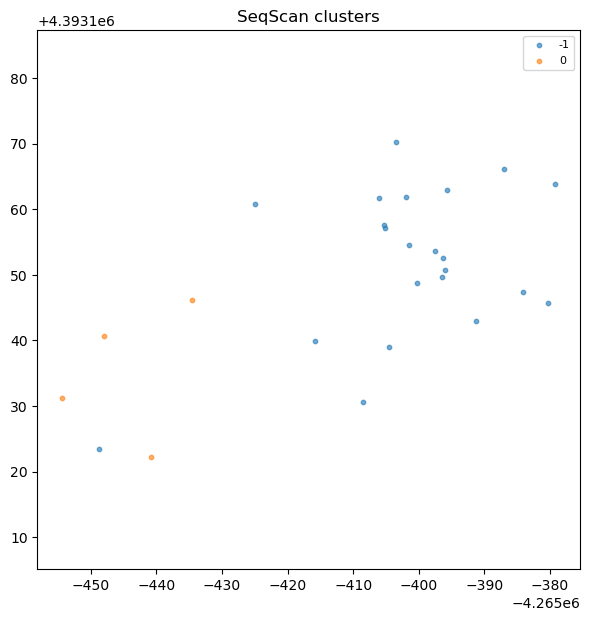

In [10]:

def plot_labels_xy(df, label_col="sw_label", title="Sliding-window labels"):
    plt.figure(figsize=(7,7))
    labels = df[label_col].to_numpy()
    for lab in sorted(set(labels)):
        sub = df[labels == lab]
        plt.scatter(sub["x"], sub["y"], s=10, alpha=0.6, label=str(lab))
    plt.title(title)
    plt.legend(loc="best", fontsize=8)
    plt.axis("equal")
    plt.show()

plot_labels_xy(sw, "sw_label", "SeqScan clusters")


In [32]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN

def compute_presence(mask_in_region: np.ndarray, timestamps: np.ndarray) -> float:
    """
    Presence = sum of dt for consecutive points that are BOTH in the region.
    mask_in_region: boolean array length m (window length)
    timestamps: array length m (seconds)
    """
    if len(timestamps) <= 1:
        return 0.0
    in_both = mask_in_region[:-1] & mask_in_region[1:]
    dt = timestamps[1:] - timestamps[:-1]
    return float(np.sum(dt[in_both]))


def first_cluster_with_presence(
    X: np.ndarray,
    t: np.ndarray,
    eps: float,
    min_samples: int,
    delta: float,
):
    """
    Run DBSCAN on X (shape m x 2) and return:
      - labels (length m)
      - best_cluster_id (an int) for the FIRST cluster that meets presence >= delta
        "first" = smallest cluster id by sklearn label ordering
      - mask for that cluster (length m) if found, else None
      - cut_rel: index of latest core point in that cluster (relative index), else None

    If no cluster meets delta -> returns (labels, None, None, None)
    """
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X)

    cluster_ids = sorted([c for c in set(labels) if c != -1])
    if not cluster_ids:
        return labels, None, None, None

    core_rel = set(getattr(db, "core_sample_indices_", []))

    for cid in cluster_ids:
        mask = (labels == cid)
        pres = compute_presence(mask, t)
        if pres >= delta:
            core_in = [i for i in np.where(mask)[0] if i in core_rel]
            if core_in:
                cut_rel = max(core_in)      # latest core point
            else:
                cut_rel = int(np.max(np.where(mask)[0]))  # fallback
            return labels, cid, mask, cut_rel

    return labels, None, None, None


def seqscan_simple(
    df: pd.DataFrame,
    eps: float,
    min_samples: int,
    delta: float,              # presence threshold in seconds
    x_col: str = "x",
    y_col: str = "y",
    t_col: str = "timestamp",
    user_id: str | None = None,
):
    """
    Simple SeqScan:
      - scan forward in time
      - maintain one active stay region at a time
      - only accept (close) stays that satisfy presence >= delta

    Output:
      - seqscan_label: 0,1,2,... for stay regions; -1 for noise/transition
    """
    data = df.copy()
    if user_id is not None:
        data = data.loc[data["user_id"] == user_id].copy()

    data = data.sort_values(t_col, kind="mergesort").reset_index(drop=True)
    n = len(data)
    if n == 0:
        data["seqscan_label"] = []
        return data

    X_all = data[[x_col, y_col]].to_numpy()
    t_all = data[t_col].to_numpy().astype(float)

    out_label = np.full(n, -1, dtype=int)
    current_label = 0

    # c is the scan pointer (like Algorithm 1)
    c = 0

    # --- Step 1: find the first stay region ---
    # grow a window until some cluster meets presence >= delta
    start = 0
    end = 0
    active_start = None
    active_end = None

    while True:
        if end >= n:
            data["seqscan_label"] = out_label
            return data

        labels, cid, mask, cut_rel = first_cluster_with_presence(
            X_all[start:end+1], t_all[start:end+1], eps, min_samples, delta
        )

        if cid is None:
            end += 1
            continue

        # Found initial stay region in [start, end]
        active_start = start
        active_end = start + cut_rel  # we treat cut as current end of the active stay
        active_mask_window = mask     # mask in the current window
        c = end + 1                   # continue scanning after end
        break

    # --- Step 2: sequentially scan for next stays ---
    # We keep extending the "search tail" and when we find a NEW stay after active_end,
    # we close the active stay and move on.
    search_start = active_end + 1
    search_end = search_start

    while True:
        # if we ran out of points, flush the active stay using what we have
        if search_start >= n:
            # finalize active stay from active_start..active_end based on DBSCAN in that segment
            labels, cid, mask, cut_rel = first_cluster_with_presence(
                X_all[active_start:active_end+1], t_all[active_start:active_end+1], eps, min_samples, 0.0
            )
            # label points that belong to that (only cluster id found)
            if cid is not None:
                out_label[active_start:active_end+1][mask] = current_label
            data["seqscan_label"] = out_label
            return data

        if search_end >= n:
            # flush similarly
            labels, cid, mask, cut_rel = first_cluster_with_presence(
                X_all[active_start:n], t_all[active_start:n], eps, min_samples, 0.0
            )
            if cid is not None:
                out_label[active_start:n][mask] = current_label
            data["seqscan_label"] = out_label
            return data

        # Try to find the NEXT stay region in the tail [search_start, search_end]
        labels, cid, mask, cut_rel = first_cluster_with_presence(
            X_all[search_start:search_end+1], t_all[search_start:search_end+1], eps, min_samples, delta
        )

        if cid is None:
            search_end += 1
            continue

        # Found next stay region in tail. Now CLOSE the active stay.
        # We'll label the active stay by running DBSCAN on its time-span and taking the cluster
        # that meets presence >= delta (or just the first cluster if you prefer).
        labels_a, cid_a, mask_a, cut_rel_a = first_cluster_with_presence(
            X_all[active_start:search_start], t_all[active_start:search_start], eps, min_samples, delta
        )

        if cid_a is not None:
            out_label[active_start:search_start][mask_a] = current_label
        current_label += 1

        # Start new active stay at the tail stay's cut point
        new_active_start = search_start
        new_active_end = search_start + cut_rel

        active_start = new_active_start
        active_end = new_active_end

        # reset tail search to start after the new active end
        search_start = active_end + 1
        search_end = search_start


In [33]:
seq = seqscan_simple(
    sparse_df,
    user_id="admiring_mestorf",
    eps=25,
    min_samples=3,
    delta=30*60,   # 30 minutes of presence, in seconds (tune!)
)
seq["seqscan_label"].value_counts()


seqscan_label
2    14
1     7
0     5
Name: count, dtype: int64

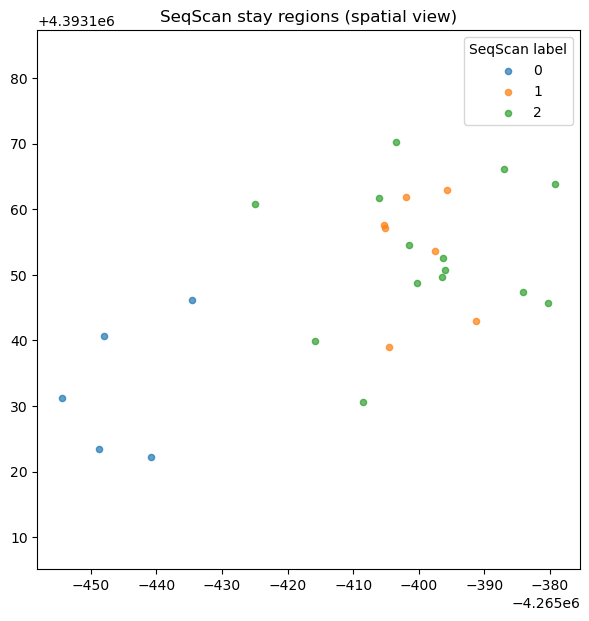

In [35]:
import matplotlib.pyplot as plt

def plot_seqscan_xy(df, label_col="seqscan_label"):
    plt.figure(figsize=(7,7))
    for lab in sorted(df[label_col].unique()):
        sub = df[df[label_col] == lab]
        plt.scatter(
            sub["x"], sub["y"],
            s=20,
            alpha=0.7,
            label=str(lab)
        )
    plt.axis("equal")
    plt.legend(title="SeqScan label")
    plt.title("SeqScan stay regions (spatial view)")
    plt.show()

plot_seqscan_xy(seq)
